In [25]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
iris_data = load_iris()

X = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
y = pd.Series(iris_data.target)

In [14]:
X_train, X_test, y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
y_pred = svm_clf.predict(X_test_scaled)

In [20]:
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("\n Classification Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

 Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

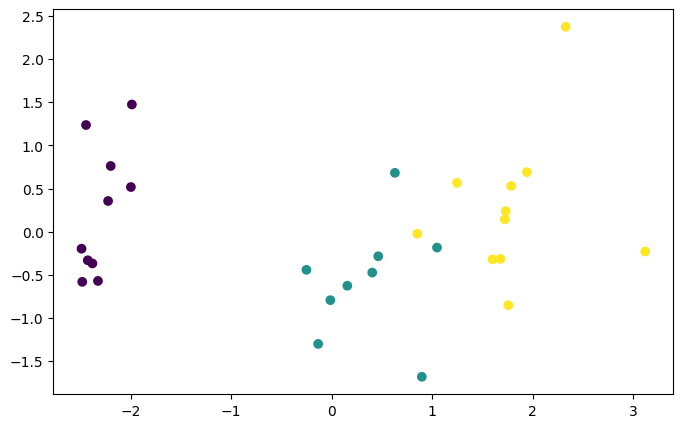

In [31]:
plt.figure(figsize=(8,5))

# 예측 값 시각화
plt.scatter(
    X_test_pca[:, 0], # PCA 1차원 축
    X_test_pca[:, 1], # PCA 2차원 축
    c=y_pred,
    cmap='viridis',
    marker='o',
    label='Predicted'
)


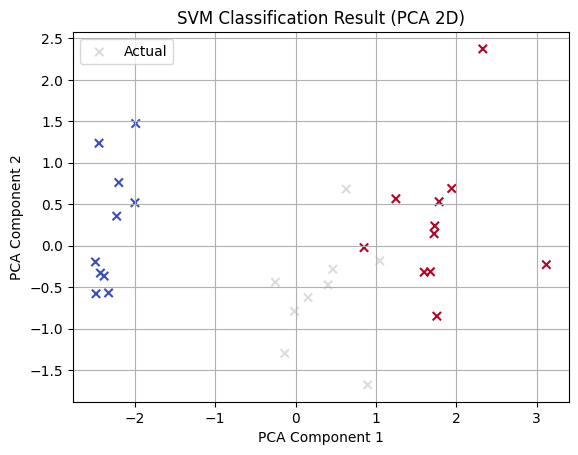

In [32]:
# 실제 라벨 위치를 X 모양으로 표시
plt.scatter(
    X_test_pca[:, 0], 
    X_test_pca[:, 1],
    c=y_test, # 실제 클래스
    cmap='coolwarm',
    marker='x',
    label='Actual'
)

plt.title("SVM Classification Result (PCA 2D)")
plt.xlabel("PCA Component 1")#
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

## 랜덤 포레스트

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.decomposition import PCA

In [34]:
iris = datasets.load_iris()

x = iris.data
y = iris.target

In [36]:
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 랜덤 포레스트 모델 생성

In [38]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

In [39]:
# 모델 학습 (rf_clf 객체를 사용하여 학습용 데이터로 fit)
rf_clf.fit(X_train_scaled, y_train)

# 테스트 데이터에 대한 예측
y_pred_rf = rf_clf.predict(X_test_scaled)


print("\n--- RandomForest 모델 평가 ---")

# 1. 혼동 행렬 (Confusion Matrix) 출력
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

# 2. 분류 보고서 (Classification Report) 출력
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))


--- RandomForest 모델 평가 ---
Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [40]:

pca = PCA(n_components=2, random_state=42)

# 스케일링된 학습 데이터에 fit 후 transform
pca.fit(X_train_scaled)

# 테스트 데이터도 동일하게 transform
X_test_pca = pca.transform(X_test_scaled)

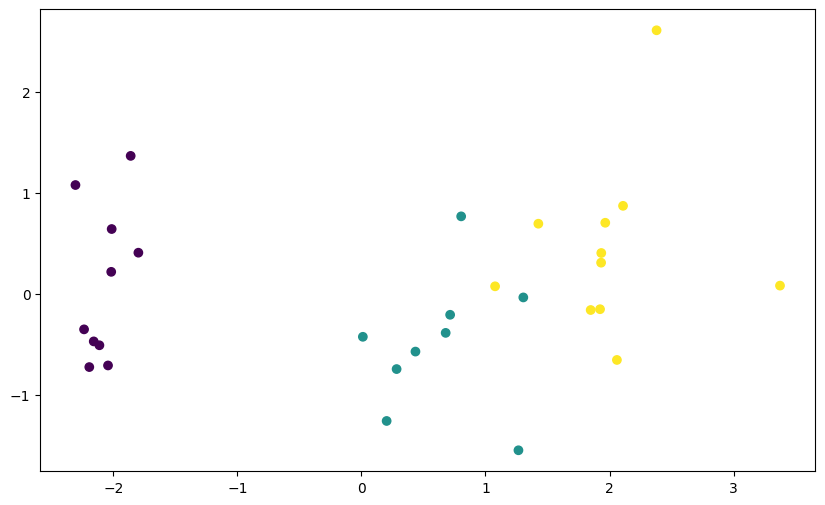

In [42]:

plt.figure(figsize=(10, 6))

# --- 1. 예측 값 (Predicted) 시각화 ---
# 'o' 마커로 예측된 클래스 위치 표시
plt.scatter(
    X_test_pca[:, 0], # PCA 1차원 축
    X_test_pca[:, 1], # PCA 2차원 축
    c=y_pred_rf, # RandomForest의 예측 결과 사용
    cmap='viridis',
    marker='o',
    label='Predicted'
)

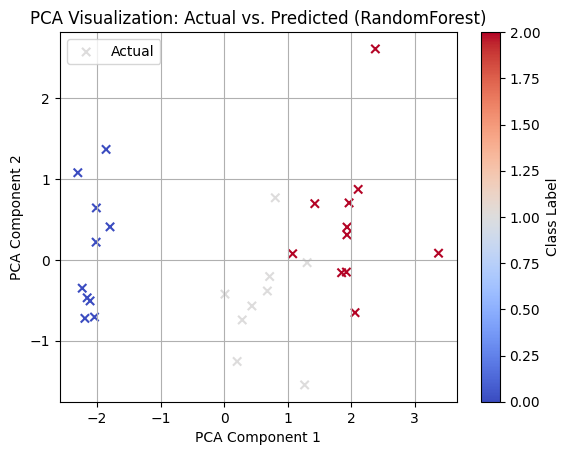

In [43]:
# --- 2. 실제 값 (Actual) 시각화 ---
# 실제 라벨 위치를 'x' 마커로 표시 (오류 확인 용이)
plt.scatter(
    X_test_pca[:, 0], 
    X_test_pca[:, 1],
    c=y_test, # 실제 클래스
    cmap='coolwarm',
    marker='x',
    label='Actual'
)

plt.title('PCA Visualization: Actual vs. Predicted (RandomForest)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.colorbar(label='Class Label')
plt.grid(True)
plt.show()